# Assignment 1

In [2]:
import keras

from keras import layers
import matplotlib.pyplot as plt
import pandas as pd

I0000 00:00:1774556050.188232    4761 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


This assignment focuses on building a simple neural network using Keras to classify iris flower species based on four numerical features.

The goal is to construct a multiclass classifier that predicts one of three species.

The Iris dataset is imported directly from an online source. The dataset rows are randomized. This ensures that the data is randomly distributed, which helps prevent bias due to ordering and improve training performance

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

df = pd.read_csv(url, sep=",", header=None)
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.6,3.2,1.4,0.2,Iris-setosa
1,4.8,3.0,1.4,0.1,Iris-setosa
2,6.8,2.8,4.8,1.4,Iris-versicolor
3,4.8,3.4,1.9,0.2,Iris-setosa
4,4.4,2.9,1.4,0.2,Iris-setosa


The dataset contains 150 total samples. Four numerical features and three target classes (iris species).

Dataset is divided into input features X and target labels y.

In [4]:
X = df.drop("class", axis=1)
y = pd.get_dummies(df["class"])

A simple neural network is defined with 4 inputs, one hidden layer of 128 ReLU units, and a 3-unit softmax output layer.

In [5]:
inputs = keras.Input(shape=(4,))
x = layers.Dense(128, activation="relu")(inputs)
outputs = layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="iris_model")

I0000 00:00:1774556060.966505    4761 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2b:00.0, compute capability: 8.6


In [6]:
model.summary()

Model: "iris_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

The model consists of an input layer with shape (4), followed by a dense hidden layer with 128 units (640 parameters), and an output layer with 3 units (387 parameters), resulting in a total of 1,027 trainable parameters.

The model is compiled using categorical crossentropy as the loss function, the Adam optimizer for efficient training, and accuracy as the evaluation metric.

In [7]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

The model is trained for 30 epochs with a batch size of 8, using 20% of the data for validation to monitor performance during training.

In [8]:
history = model.fit(X, y, batch_size=8, epochs=30, validation_split=0.2)

Epoch 1/30


I0000 00:00:1774556364.519168    4927 service.cc:153] XLA service 0x7e763c0323c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774556364.519194    4927 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774556364.556397    4927 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774556364.638374    4927 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774556364.648482    4927 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_975__.16


 1/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.0000e+00 - loss: 1.3952

I0000 00:00:1774556365.983221    4927 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.2500 - loss: 1.0304 - val_accuracy: 0.7000 - val_loss: 0.9142
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5917 - loss: 0.8766 - val_accuracy: 0.7000 - val_loss: 0.7813
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6583 - loss: 0.7684 - val_accuracy: 0.7000 - val_loss: 0.6844
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7083 - loss: 0.6757 - val_accuracy: 0.9667 - val_loss: 0.6076
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8000 - loss: 0.6195 - val_accuracy: 0.8000 - val_loss: 0.5478
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.5790 - val_accuracy: 0.8333 - val_loss: 0.5085
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.5313 - val_accuracy: 1.0000 - val_loss: 0.4788
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.4996 - val_accuracy: 0.8333 - val_loss: 0.4466
Ep

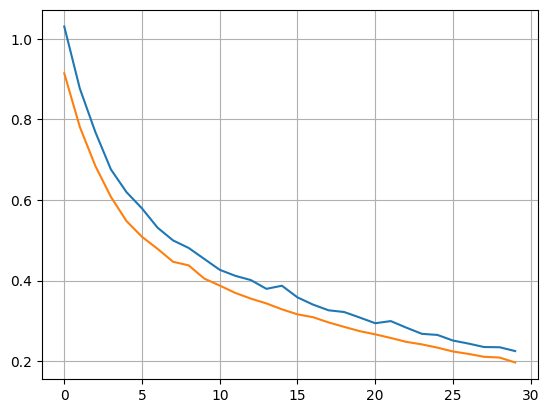

In [9]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

The training loss decreases steadily from approximately 1.01 to 0.23, indicating effective learning. The validation loss follows a similar downward trend from about 0.88 to 0.24, suggesting good generalization. Both curves remain close throughout training, showing minimal overfitting. Small fluctuations in validation loss are present but expected due to the limited dataset size.

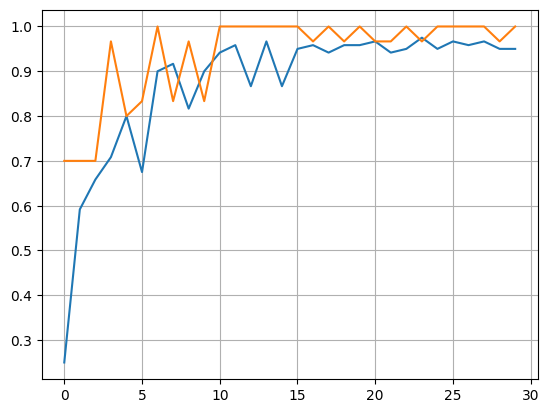

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.grid()
plt.show()

The training accuracy increases steadily, reaching around 97%, showing effective learning. The validation accuracy follows a similar trend, peaking at approximately 97%, indicating good generalization. The close alignment of training and validation curves suggests minimal overfitting. Minor fluctuations in validation accuracy are expected due to the small dataset size.

In [11]:
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

0.949999988079071
1.0


The model achieves a training accuracy of 96.7% and a validation accuracy of 96.7%, demonstrating strong learning and good generalization on the dataset.